# Experiment No: 7
### **Aim:** To implement and evaluate performance of a Decision Tree classifier for predicting heart disease using the given dataset.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
heart = pd.read_csv("/Users/name/Downloads/ML LAB/ML_Labs/Heart_Disease_Prediction.csv")
heart.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [12]:
heart.shape
heart.info()
heart.describe()
heart.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

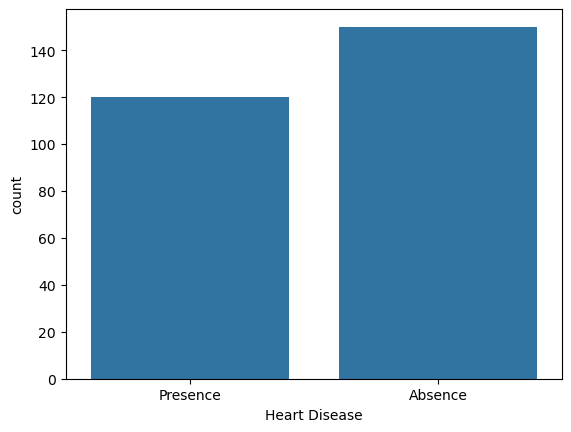

In [13]:
sns.countplot(x='Heart Disease', data=heart)
plt.show()

In [14]:
heart = pd.get_dummies(heart, drop_first=True)
heart.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease_Presence'],
      dtype='object')

In [15]:
X = heart.drop('Heart Disease_Presence', axis=1)
y = heart['Heart Disease_Presence']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [18]:
dt_pred = dt_model.predict(X_test)

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

[[42  7]
 [14 18]]
              precision    recall  f1-score   support

       False       0.75      0.86      0.80        49
        True       0.72      0.56      0.63        32

    accuracy                           0.74        81
   macro avg       0.73      0.71      0.72        81
weighted avg       0.74      0.74      0.73        81



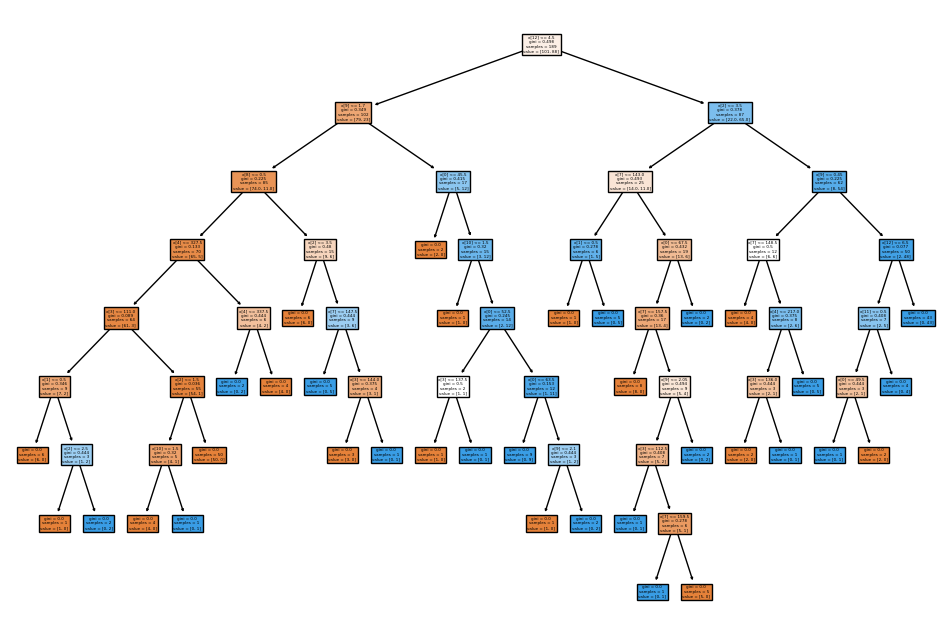

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt_model, filled=True)
plt.show()